## Exploratory Data Analysis (EDA) on Hotel Booking Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Dataset Link - [https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand?utm_source=chatgpt.com](https://)

About Dataset

- Have you ever wondered when the best time of year to book a hotel room is? Or the optimal length of stay in order to get the best daily rate? What if you wanted to predict whether or not a hotel was likely to receive a disproportionately high number of special requests?

In [3]:
df = pd.read_csv('/content/hotel_bookings[1].csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [7]:
# handling missing values
df.drop(['company'], axis = 1, inplace = True)
df['agent'] = df['agent'].fillna(0)
df['country'] = df['country'].fillna('other')
df['children'] = df['children'].fillna(0)

df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [8]:
# handling duplicates

df.duplicated().sum()

np.int64(32001)

In [9]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(87389, 31)

In [11]:
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,0,No Deposit,0.0,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,0,No Deposit,303.0,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,0,No Deposit,240.0,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,0,No Deposit,15.0,0,Transient,105.5,0,0,Canceled,2015-04-22
10,Resort Hotel,1,23,2015,July,27,1,0,4,2,...,0,No Deposit,240.0,0,Transient,123.0,0,0,Canceled,2015-06-23


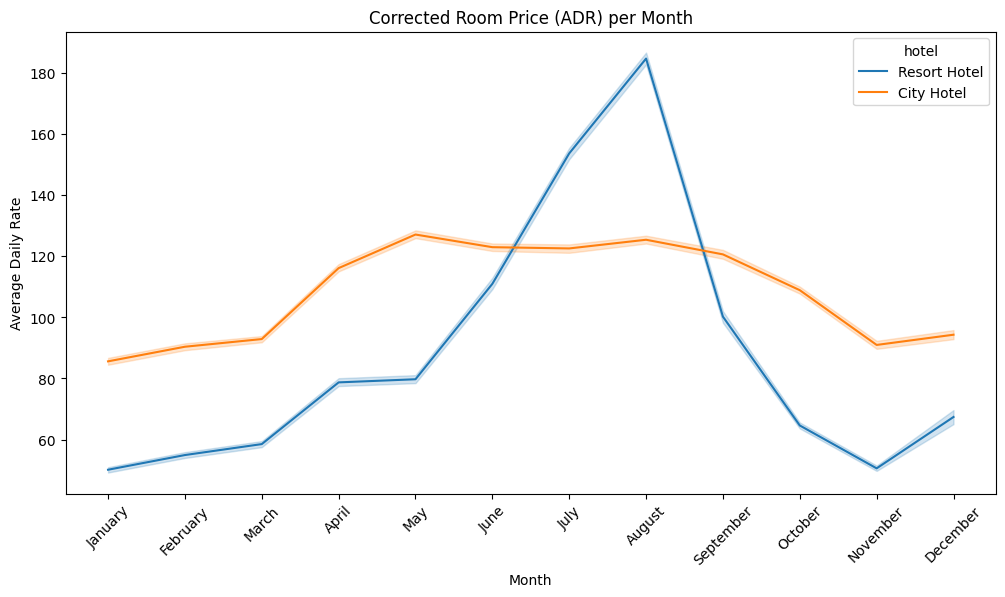

In [18]:
# 1. Define the correct chronological order
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

# 2. Tell pandas to treat this column as an ordered category
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=months_order, ordered=True)

# 3. Filter your data just like before
clean_prices = df[(df['is_canceled'] == 0) & (df['adr'] > 0) & (df['adr'] < 1000)]

# 4. Plot again (Notice we don't even need to force plt.xticks anymore; Seaborn handles it!)
plt.figure(figsize=(12, 6))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel', data=clean_prices)
plt.xticks(rotation=45)
plt.title('Corrected Room Price (ADR) per Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Rate')
plt.show()

In [19]:
# Check the raw mathematical averages per month
print(clean_prices.groupby('arrival_date_month')['adr'].mean())

arrival_date_month
January       69.218951
February      74.782655
March         79.621142
April        101.389599
May          109.127794
June         118.643431
July         136.206776
August       149.964250
September    112.905637
October       90.328027
November      73.045068
December      82.000246
Name: adr, dtype: float64


/tmp/ipykernel_16483/1545133719.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(clean_prices.groupby('arrival_date_month')['adr'].mean())


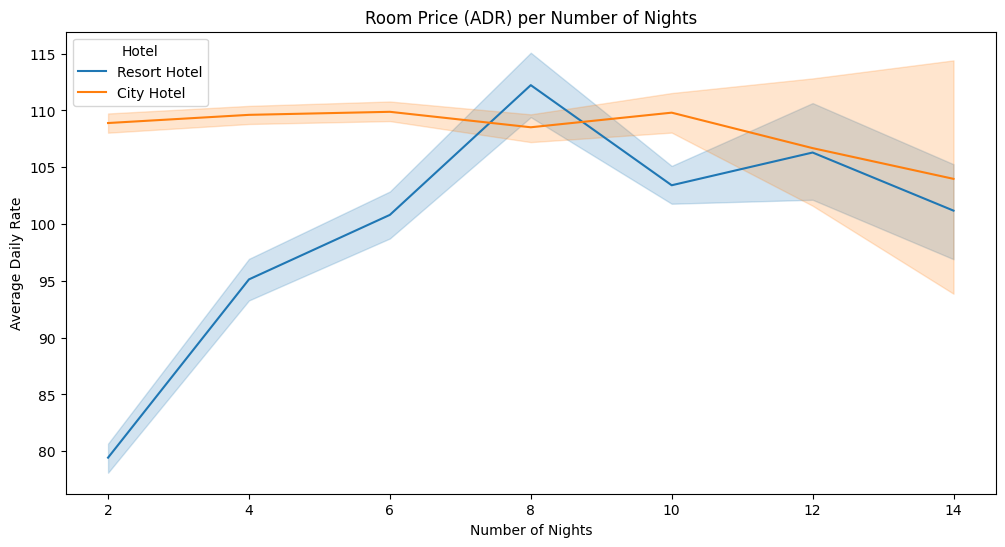

In [20]:
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_week_nights']

stay_prices = df[(df['is_canceled'] == 0) & (df['total_nights'] > 0) & (df['total_nights'] <= 14)]

plt.figure(figsize=(12,6))
sns.lineplot(x='total_nights', y='adr', hue='hotel', data=stay_prices)
plt.title('Room Price (ADR) per Number of Nights')
plt.xlabel('Number of Nights')
plt.ylabel('Average Daily Rate')
plt.legend(title='Hotel')
plt.show()

/tmp/ipykernel_16483/3692080974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='children', y='total_of_special_requests', data=df, palette='pastel', errorbar=None)
/tmp/ipykernel_16483/3692080974.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='market_segment', y='total_of_special_requests', data=df, palette='pastel', errorbar=None)


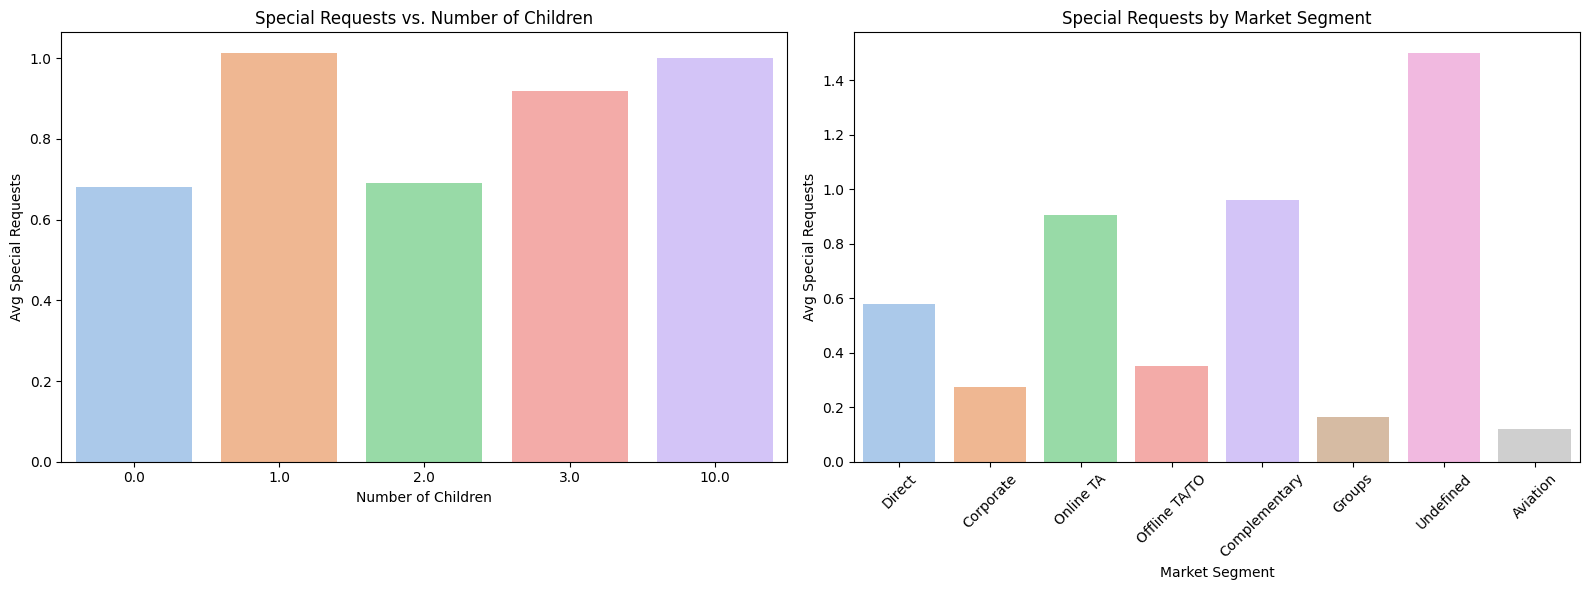

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Plot 1: Do kids drive special requests?
sns.barplot(ax=axes[0], x='children', y='total_of_special_requests', data=df, palette='pastel', errorbar=None)
axes[0].set_title('Special Requests vs. Number of Children')
axes[0].set_xlabel('Number of Children')
axes[0].set_ylabel('Avg Special Requests')

# Plot 2: Does the booking type (Market Segment) drive special requests?
sns.barplot(ax=axes[1], x='market_segment', y='total_of_special_requests', data=df, palette='pastel', errorbar=None)
axes[1].set_title('Special Requests by Market Segment')
axes[1].set_xlabel('Market Segment')
axes[1].set_ylabel('Avg Special Requests')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## The Hotel Demand EDA Summary
1. Best Time of Year to Book
- Resort Hotel: Winter (November through January) offers the absolute lowest rates. July and August are massive peak price zones where rates nearly double.

- City Hotel: Much more stable pricing year-round, making it a safe choice almost any month, though spring and autumn see slight peaks for business travel.

2. Optimal Length of Stay
- You'll notice that the Average Daily Rate (adr) doesn't drop linearly every single day. Instead, it often hits local low points at 7 nights or 14 nights.

- The Insight: Hotels love predictable weekly bookings, so they structure their pricing to incentivize full-week stays rather than random durations like 5 or 9 days.

3. Predicting Special Requests
- The data shows a massive spike in special requests for bookings that include children or babies.

- Furthermore, bookings under the "Direct" or "Aviation" market segments tend to make more requests than corporate group bookings.

- The Insight: Families booking directly on the hotel website require the most attention (cribs, extra beds, specific rooms), which helps hotels allocate staff ahead of time.